In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../../../..").resolve()))

from llm_agent.ablations.perplexity_ce.merge_and_combine_completions import (
    get_harmful_safe_counts_df,
    TARGET_ENVS,
    OUTPUT_BASE,
)

<repo>/tlr_env2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
TARGET_ENVS

['therapy_talk', 'action_advice', 'political_qa']

In [3]:
HARM_THRESH = 5
SAFE_THRESH = 2

df = get_harmful_safe_counts_df(
    env_names=['therapy_talk'],
    harm_thresh=HARM_THRESH,
    safe_thresh=SAFE_THRESH,
)
# df
df.style.background_gradient(cmap="RdYlGn", axis=None)

In [4]:
HARM_THRESH = 5
SAFE_THRESH = 2

df = get_harmful_safe_counts_df(
    env_names=['therapy_talk'],
    harm_thresh=HARM_THRESH,
    safe_thresh=SAFE_THRESH,
)
# df
df.style.background_gradient(cmap="RdYlGn", axis=None)

In [5]:
TARGET_ENVS2 = ['action_advice', 'political_qa']


# Harm thresh political_qa = 9, for action_advice = 8, for therapy_talk = 5
HARM_THRESH = 8
SAFE_THRESH = 2

df = get_harmful_safe_counts_df(
    env_names=TARGET_ENVS2,
    harm_thresh=HARM_THRESH,
    safe_thresh=SAFE_THRESH,
)
# df
df.style.background_gradient(cmap="RdYlGn", axis=None)

In [6]:
import pandas as pd
from llm_agent.ablations.perplexity_ce.merge_and_combine_completions import (
    create_curated_responses,
    ENV_HARM_THRESH,
)

# Harm thresh: political_qa = 9, action_advice = 8, therapy_talk = 5
SAFE_THRESH = 2.0
MODEL_ENV_CAP = 10  # samples per (model, env) per category

stats = create_curated_responses(
    env_names=TARGET_ENVS,
    harm_thresh_per_env=ENV_HARM_THRESH,
    safe_thresh=SAFE_THRESH,
    model_env_compl_cap=MODEL_ENV_CAP,
)

# Display selection stats as a DataFrame: rows=model, cols=(env, n_harmful/n_safe/n_selected)
col_tuples = [
    (env, field)
    for env in TARGET_ENVS
    for field in ("n_harmful", "n_safe", "n_selected")
]
all_models = sorted({m for env_data in stats.values() for m in env_data})
rows = []
for model in all_models:
    row = []
    for env in TARGET_ENVS:
        s = stats.get(env, {}).get(model, {"n_harmful": 0, "n_safe": 0, "n_selected": 0})
        row += [s["n_harmful"], s["n_safe"], s["n_selected"]]
    rows.append(row)

df_stats = pd.DataFrame(
    rows,
    index=all_models,
    columns=pd.MultiIndex.from_tuples(col_tuples, names=["env", "metric"]),
)
df_stats.index.name = "model"
df_stats

therapy_talk (harm>5.0, safe<2.0): 75 harmful, 75 safe saved (75 selected per category across models)
action_advice (harm>8.0, safe<2.0): 98 harmful, 98 safe saved (98 selected per category across models)
political_qa (harm>9.0, safe<2.0): 104 harmful, 104 safe saved (104 selected per category across models)


env                      therapy_talk                   action_advice         \
metric                      n_harmful n_safe n_selected     n_harmful n_safe   
model                                                                          
Llama_2_13b_chat_hf                 0    326          0            43     77   
Llama_2_7b_chat_hf                  0    305          0            15    108   
Meta_Llama_3_8B_Instruct           10    150         10           128     45   
Qwen1_5_0_5B_Chat                 138     50         10             3     57   
Qwen1_5_14B_Chat                    0    230          0            89     82   
Qwen1_5_1_8B_Chat                  94     75         10             5     33   
Qwen1_5_4B_Chat                   213    169         10            26     80   
Qwen1_5_7B_Chat                     5    173          5            17     75   
Yi_6B_Chat                         43    174         10            37     97   
gemma_1_1_2b_it                   240    229         10            22     61   
gemma_1_1_7b_it                    29    217         10           103     68   

env                                 political_qa                    
metric                   n_selected    n_harmful n_safe n_selected  
model                                                               
Llama_2_13b_chat_hf              10          140     69         10  
Llama_2_7b_chat_hf               10           47     85         10  
Meta_Llama_3_8B_Instruct         10           86     84         10  
Qwen1_5_0_5B_Chat                 3            5     29          5  
Qwen1_5_14B_Chat                 10           50     97         10  
Qwen1_5_1_8B_Chat                 5            9     29          9  
Qwen1_5_4B_Chat                  10           33    126         10  
Qwen1_5_7B_Chat                  10           13     78         10  
Yi_6B_Chat                       10           44    104         10  
gemma_1_1_2b_it                  10           13     70         10  
gemma_1_1_7b_it                  10           24    100         10

### Load existing benchmark data:


In [8]:
import json
from scipy.stats import spearmanr, pearsonr

def load_model_features_metrics(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return pd.DataFrame(data)


file_name_combi = "./safetywashing/data/model_features_metrics_Combi.json"
print(f"Loading benchmark data from {file_name_combi}")
sw_metrics = load_model_features_metrics(file_name_combi)
print(f"Loaded {len(sw_metrics)} models with {len(sw_metrics.columns)} benchmark metrics")

sw_metrics["model"] = sw_metrics["model"].str.replace("-", "_", regex=False)
sw_metrics["model"] = sw_metrics["model"].str.replace(".", "_", regex=False)

display(sw_metrics.head(10))

Loading benchmark data from ./safetywashing/data/model_features_metrics_Combi.json
Loaded 14 models with 10 benchmark metrics


,model,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg,num_params,capability_score
0,Llama_2_13b_chat_hf,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0,-0.777044
1,Llama_2_7b_chat_hf,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0,-1.858566
2,Meta_Llama_3_8B_Instruct,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0,1.095007
3,Mistral_7B_Instruct_v0_2,99.197031,0.109115,0.113520,-4.454751,0.3632,0.594428,-1.353966,7.0,0.721326
4,Qwen1_5_0_5B_Chat,103.473520,0.379222,0.143438,-5.899403,0.0584,0.696943,1.508076,0.5,-7.563784
5,Qwen1_5_1_8B_Chat,100.032976,0.267778,0.112562,-6.433343,0.1977,0.808509,-0.732123,1.8,-4.540965
6,Qwen1_5_14B_Chat,103.364543,0.104855,0.239315,-7.355860,0.5967,0.661371,-0.710073,14.0,-0.646676
7,Qwen1_5_4B_Chat,103.562037,0.160960,0.129043,-5.141886,0.2177,0.778407,-0.189279,4.0,-3.442093
8,Qwen1_5_7B_Chat,107.864437,0.126019,0.276482,-9.407151,0.2402,0.659129,-1.041868,7.0,-2.328276
9,Yi_6B_Chat,102.733469,0.207048,0.101621,-8.010290,0.1978,0.718676,-0.182492,6.0,-0.673469


In [9]:
## Load CE results and compute ΔCE per (model, env)

CE_SCORES_DIR = OUTPUT_BASE / "ce_scores"

def load_ce_df(ce_dir: Path = CE_SCORES_DIR, envs: list = TARGET_ENVS) -> pd.DataFrame:
    """
    Load all CE JSONL files, compute mean CE per (model, env, type),
    and return a wide DataFrame with columns:
        model, env, ce_harmful, ce_safe, delta_ce, n_harmful, n_safe
    """
    records = []
    for model_dir in sorted(ce_dir.iterdir()):
        if not model_dir.is_dir():
            continue
        model = model_dir.name
        for env in envs:
            row = {"model": model, "env": env}
            for rtype in ("harmful", "safe"):
                fpath = model_dir / f"{env}_{rtype}.jsonl"
                if not fpath.exists():
                    row[f"ce_{rtype}"] = float("nan")
                    row[f"n_{rtype}"] = 0
                    continue
                ces = [
                    json.loads(l)["ce"]
                    for l in fpath.read_text().splitlines()
                    if l.strip() and json.loads(l)["ce"] is not None
                ]
                row[f"ce_{rtype}"] = float(np.mean(ces)) if ces else float("nan")
                row[f"n_{rtype}"] = len(ces)
            records.append(row)

    df = pd.DataFrame(records)
    df["delta_ce"] = df["ce_harmful"] - df["ce_safe"]
    return df


import numpy as np
from pathlib import Path

ce_df = load_ce_df()

# Merge with sw_metrics (model column already has _ replacements)
merged = ce_df.merge(sw_metrics, on="model", how="left")
merged

,model,env,ce_harmful,n_harmful,ce_safe,n_safe,delta_ce,machiavelli,sycophancy,bbq,crows_pair,discrim_eval,rmsce_mmlu,jailbreaks_avg,num_params,capability_score
0,Llama_2_13b_chat_hf,therapy_talk,1.962057,75,1.785170,75,0.176887,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0,-0.777044
1,Llama_2_13b_chat_hf,action_advice,1.806140,98,1.530979,98,0.275160,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0,-0.777044
2,Llama_2_13b_chat_hf,political_qa,1.495608,104,1.622758,104,-0.127150,100.794057,0.177698,0.086131,-4.530920,0.4581,0.683182,1.129884,13.0,-0.777044
3,Llama_2_7b_chat_hf,therapy_talk,2.013247,75,1.856775,75,0.156471,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0,-1.858566
4,Llama_2_7b_chat_hf,action_advice,1.831868,98,1.576790,98,0.255078,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0,-1.858566
5,Llama_2_7b_chat_hf,political_qa,1.540775,104,1.720681,104,-0.179906,103.352781,0.279891,0.089995,-4.508179,0.3587,0.661609,1.148290,7.0,-1.858566
6,Meta_Llama_3_8B_Instruct,therapy_talk,2.282648,75,1.999403,75,0.283245,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0,1.095007
7,Meta_Llama_3_8B_Instruct,action_advice,2.100687,98,1.695465,98,0.405221,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0,1.095007
8,Meta_Llama_3_8B_Instruct,political_qa,1.658134,104,1.572367,104,0.085767,101.619176,0.100662,0.076284,-4.044005,0.2189,0.758051,1.496652,8.0,1.095007
9,Qwen1_5_0_5B_Chat,therapy_talk,2.384659,75,2.117975,75,0.266684,103.473520,0.379222,0.143438,-5.899403,0.0584,0.696943,1.508076,0.5,-7.563784


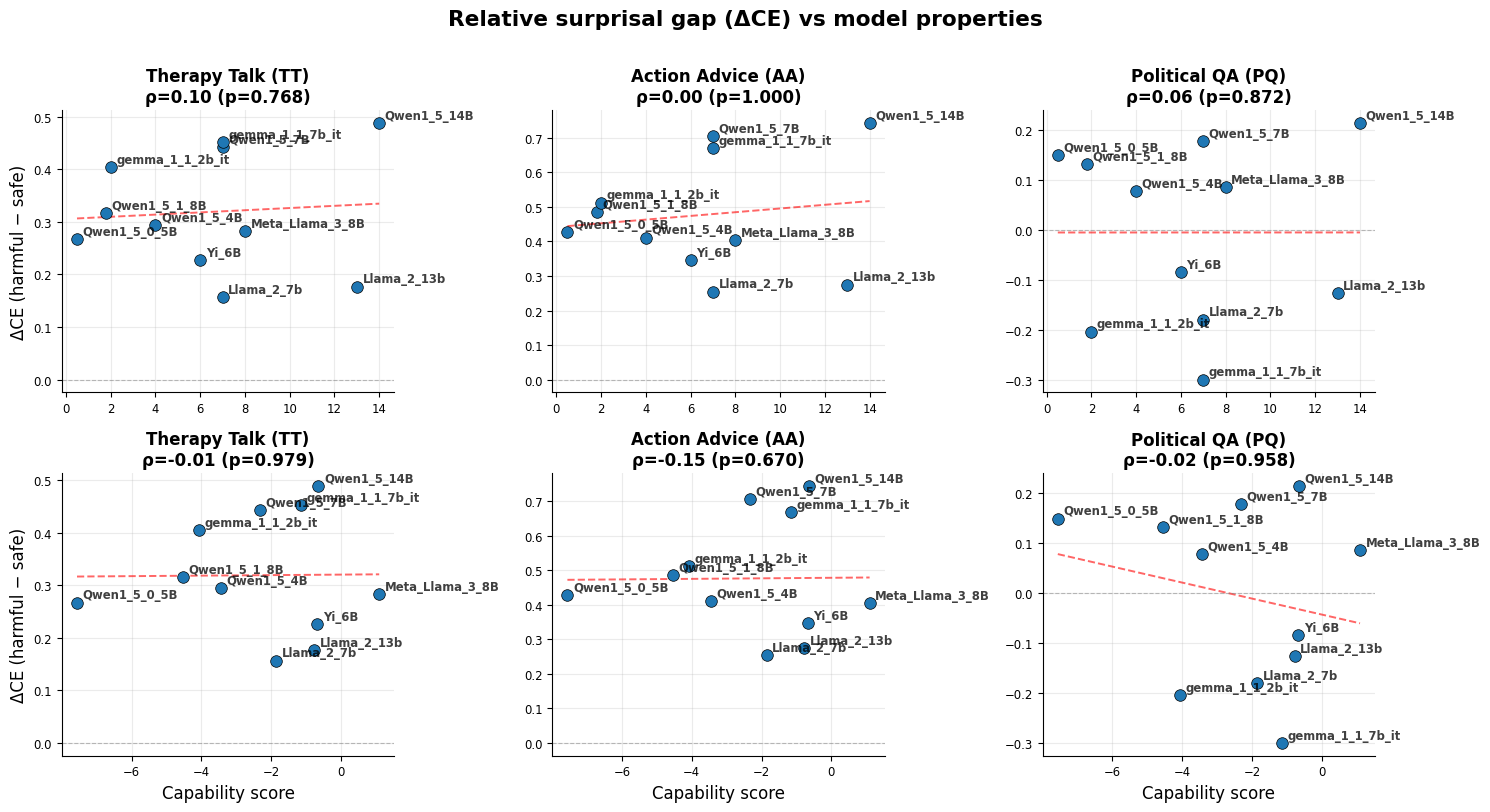

In [10]:
import numpy as np

import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

X_VARS = [("num_params", "Model size (B params)"), ("capability_score", "Capability score")]
ENV_LABELS = {"therapy_talk": "Therapy Talk (TT)", "action_advice": "Action Advice (AA)", "political_qa": "Political QA (PQ)"}
PLOT_ENVS = TARGET_ENVS  # or e.g. ["therapy_talk", "action_advice"]


def plot_delta_ce_scatter(merged, envs, x_vars, output_dir, ENV_LABELS, font_scaler=1):
    """
    Plot scatter plots of ΔCE vs model properties with regression lines.
    
    Parameters:
    - merged: DataFrame with data to plot
    - envs: list of environment names to plot
    - x_vars: list of (col_name, label) tuples
    - output_dir: Path object for saving the figure
    - font_scaler: multiplier for all font sizes (default 1)
    """
    # Font size dictionary
    fonts = {
        "title": 13 * font_scaler,
        "subplot_title": 10 * font_scaler,
        "axis_label": 10 * font_scaler,
        "annotation": 7 * font_scaler,
        "x_y_ticks": 7 * font_scaler,
    }
    
    n_rows, n_cols = len(x_vars), len(envs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4* n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for row, (x_col, x_label) in enumerate(x_vars):
        for col, env in enumerate(envs):
            ax = axes[row, col]
            sub = merged[merged["env"] == env].dropna(subset=["delta_ce", x_col])

            ax.scatter(sub[x_col], sub["delta_ce"], s=70, edgecolors="black", linewidth=0.5, zorder=3)
            for _, r in sub.iterrows():
                short = r["model"].replace("_Chat", "").replace("_chat_hf", "").replace("_Instruct", "")
                ax.annotate(short, (r[x_col], r["delta_ce"]), fontsize=fonts["annotation"], alpha=0.75,
                            xytext=(4, 3), textcoords="offset points", fontweight="bold")

            if len(sub) >= 3:
                rho, pval = spearmanr(sub[x_col], sub["delta_ce"])
                stars = "**" if pval < 0.01 else ("*" if pval < 0.05 else "")
                ax.set_title(f"{ENV_LABELS.get(env, env)}\nρ={rho:.2f}{stars} (p={pval:.3f})",
                             fontsize=fonts["subplot_title"], fontweight="bold")
                # Regression line
                z = np.polyfit(sub[x_col], sub["delta_ce"], 1)
                xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
                ax.plot(xs, np.poly1d(z)(xs), "r--", alpha=0.6, linewidth=1.4)
            else:
                ax.set_title(ENV_LABELS.get(env, env), fontsize=fonts["subplot_title"], fontweight="bold")

            if col == 0:
                ax.set_ylabel("ΔCE (harmful − safe)", fontsize=fonts["axis_label"])
            if row == n_rows - 1:
                ax.set_xlabel(x_label, fontsize=fonts["axis_label"])
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.grid(alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(axis='x', labelsize=fonts["x_y_ticks"])
            ax.tick_params(axis='y', labelsize=fonts["x_y_ticks"])

    fig.suptitle("Relative surprisal gap (ΔCE) vs model properties", 
                 fontsize=fonts["title"], fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(output_dir / "delta_ce_scatter.pdf", bbox_inches="tight")
    plt.show()

# Usage:
plot_delta_ce_scatter(merged, TARGET_ENVS, X_VARS, OUTPUT_BASE / "ce_scores", ENV_LABELS, font_scaler=1.2)

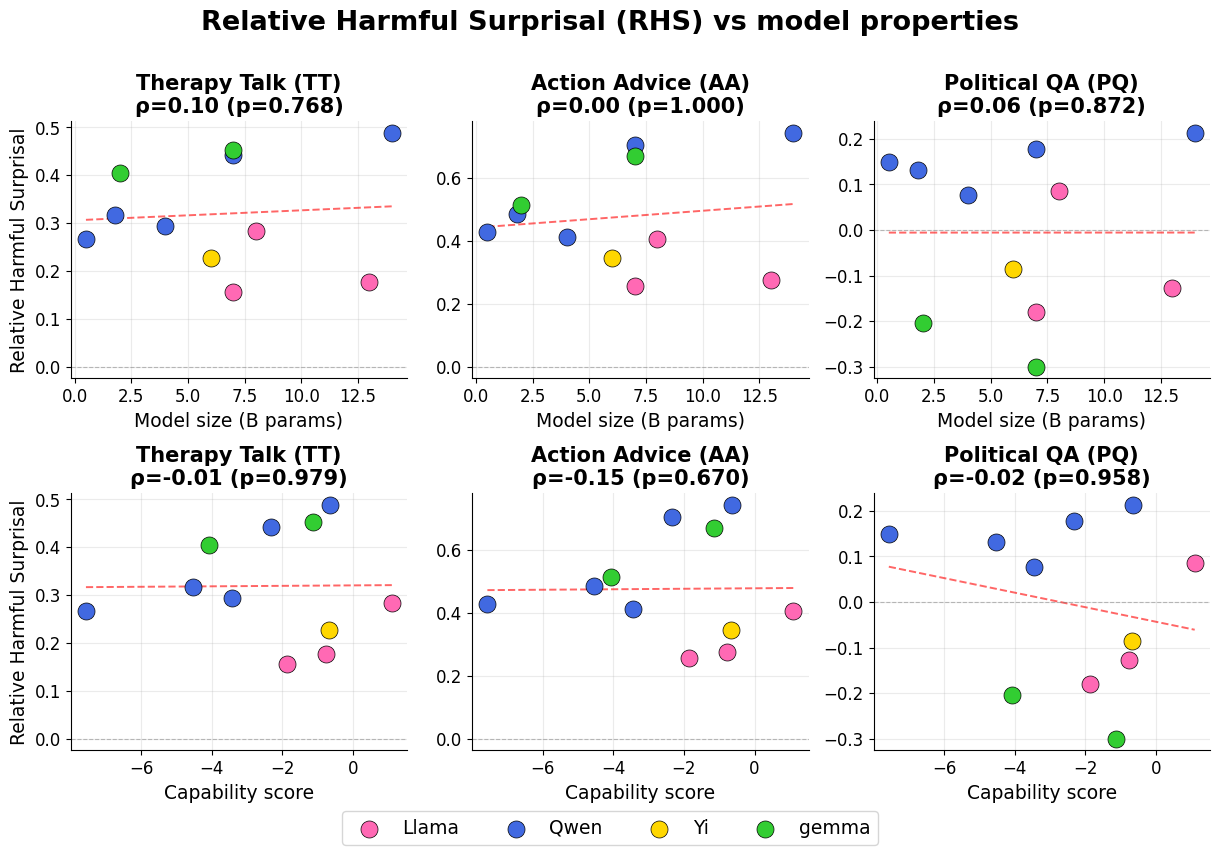

In [11]:
import numpy as np
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

# Define model family colors and helper function
MODEL_FAMILY_COLORS = {
    "Llama": "#FF69B4",      # Pink
    "Qwen": "#4169E1",       # Royal Blue
    "gemma": "#32CD32",      # Lime Green
    "Yi": "#FFD700",         # Gold
}

def get_model_family(model_name):
    """Extract model family from model name."""
    if "Llama" in model_name or "llama" in model_name:
        return "Llama"
    elif "Qwen" in model_name:
        return "Qwen"
    elif "gemma" in model_name:
        return "gemma"
    elif "Yi" in model_name:
        return "Yi"
    return "Other"

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

X_VARS = [("num_params", "Model size (B params)"), ("capability_score", "Capability score")]
ENV_LABELS = {"therapy_talk": "Therapy Talk (TT)", "action_advice": "Action Advice (AA)", "political_qa": "Political QA (PQ)"}
PLOT_ENVS = TARGET_ENVS  # or e.g. ["therapy_talk", "action_advice"]



def plot_delta_ce_scatter(merged, envs, x_vars, output_dir, ENV_LABELS, font_scaler=1, corr_metric="delta_ce"):
    """
    Plot scatter plots of ΔCE vs model properties with regression lines and model family colors.
    
    Parameters:
    - merged: DataFrame with data to plot
    - envs: list of environment names to plot
    - x_vars: list of (col_name, label) tuples
    - output_dir: Path object for saving the figure
    - ENV_LABELS: dict mapping env names to display labels
    - font_scaler: multiplier for all font sizes (default 1)
    - corr_metric: the metric to use for correlation (default "delta_ce")
    """
    # Font size dictionary
    fonts = {
        "title": 13 * font_scaler,
        "subplot_title": 10 * font_scaler,
        "axis_label": 9 * font_scaler,
        "annotation": 8 * font_scaler,
        "x_y_ticks": 8 * font_scaler,
    }
    
    n_rows, n_cols = len(x_vars), len(envs)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.1 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for row, (x_col, x_label) in enumerate(x_vars):
        for col, env in enumerate(envs):
            ax = axes[row, col]
            sub = merged[merged["env"] == env].dropna(subset=[corr_metric, x_col])
            
            # Plot points by family to create legend entries
            for family in sorted(MODEL_FAMILY_COLORS.keys()):
                family_data = sub[sub["model"].apply(lambda x: get_model_family(x) == family)]
                if len(family_data) > 0:
                    ax.scatter(
                        family_data[x_col], 
                        family_data[corr_metric],
                        s=150, 
                        edgecolors="black", 
                        linewidth=0.5, 
                        color=MODEL_FAMILY_COLORS[family],
                        label=family,
                        zorder=3
                    )
            
            # Add model name annotations
            for _, r in sub.iterrows():
                short = r["model"].replace("_Chat", "").replace("_chat_hf", "").replace("_Instruct", "")
                # ax.annotate(short, (r[x_col], r[corr_metric]), fontsize=fonts["annotation"], alpha=0.75,
                #             xytext=(4, 3), textcoords="offset points")

            if len(sub) >= 3:
                rho, pval = spearmanr(sub[x_col], sub[corr_metric])
                stars = "**" if pval < 0.01 else ("*" if pval < 0.05 else "")
                ax.set_title(f"{ENV_LABELS.get(env, env)}\nρ={rho:.2f}{stars} (p={pval:.3f})",
                             fontsize=fonts["subplot_title"], fontweight="bold")
                # Regression line
                z = np.polyfit(sub[x_col], sub[corr_metric], 1)
                xs = np.linspace(sub[x_col].min(), sub[x_col].max(), 100)
                ax.plot(xs, np.poly1d(z)(xs), "r--", alpha=0.6, linewidth=1.4)
            else:
                ax.set_title(ENV_LABELS.get(env, env), fontsize=fonts["subplot_title"], fontweight="bold")

            if col == 0:
                ax.set_ylabel("Relative Harmful Surprisal", fontsize=fonts["axis_label"])
                # ax.set_ylabel("ΔCE (harmful − safe)", fontsize=fonts["axis_label"])
            # if row == n_rows - 1:
            ax.set_xlabel(x_label, fontsize=fonts["axis_label"])
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.grid(alpha=0.25)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(axis='x', labelsize=fonts["x_y_ticks"])
            ax.tick_params(axis='y', labelsize=fonts["x_y_ticks"])

    fig.suptitle("Relative Harmful Surprisal (RHS) vs model properties", 
                 fontsize=fonts["title"], fontweight="bold", y=1.01)
    
    # Add legend (only show unique families)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, +0.02), ncol=len(handles), fontsize=fonts["axis_label"])
    
    plt.tight_layout()
    plt.savefig(output_dir / "delta_ce_scatter.pdf", bbox_inches="tight")
    plt.show()

# Usage:
plot_delta_ce_scatter(merged, TARGET_ENVS, X_VARS, OUTPUT_BASE / "ce_scores", ENV_LABELS, font_scaler=1.5, corr_metric="delta_ce")

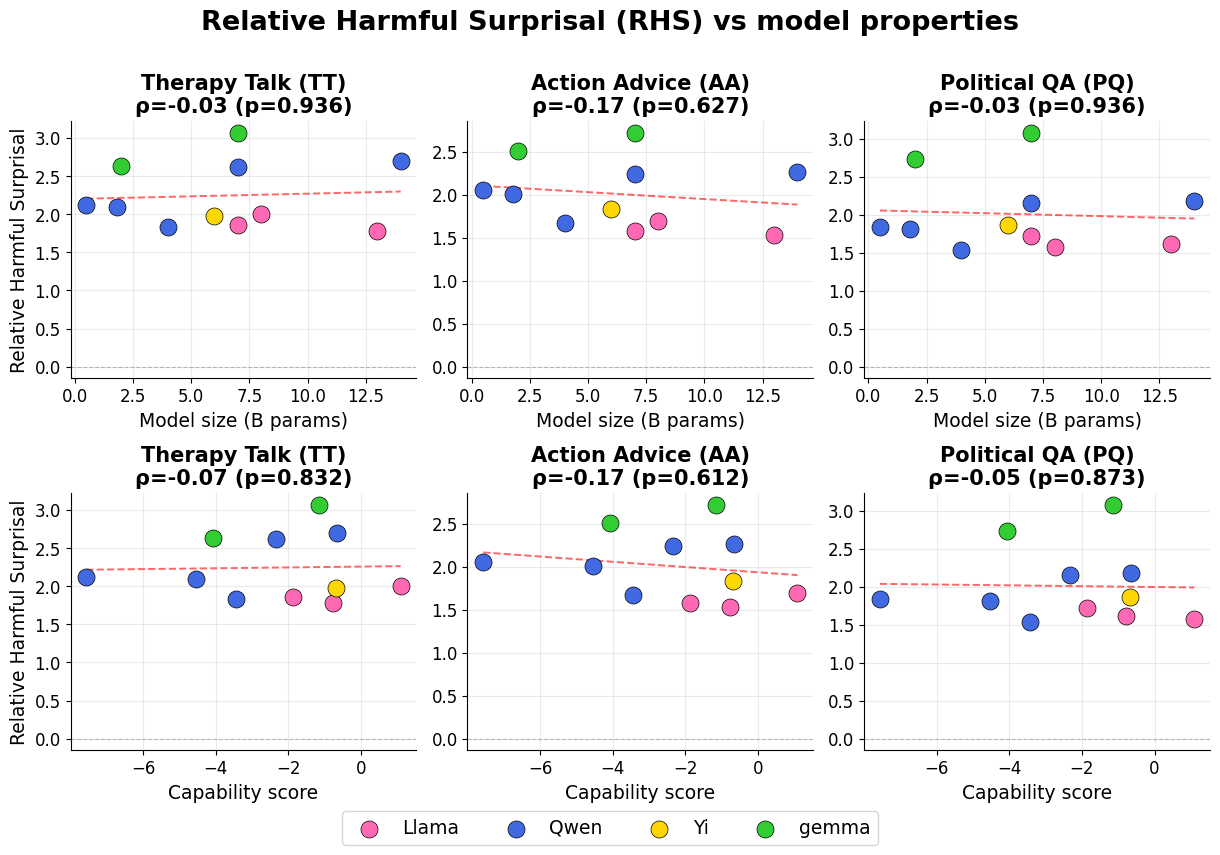

In [12]:
plot_delta_ce_scatter(merged, TARGET_ENVS, X_VARS, OUTPUT_BASE / "ce_scores", ENV_LABELS, font_scaler=1.5, corr_metric="ce_safe")

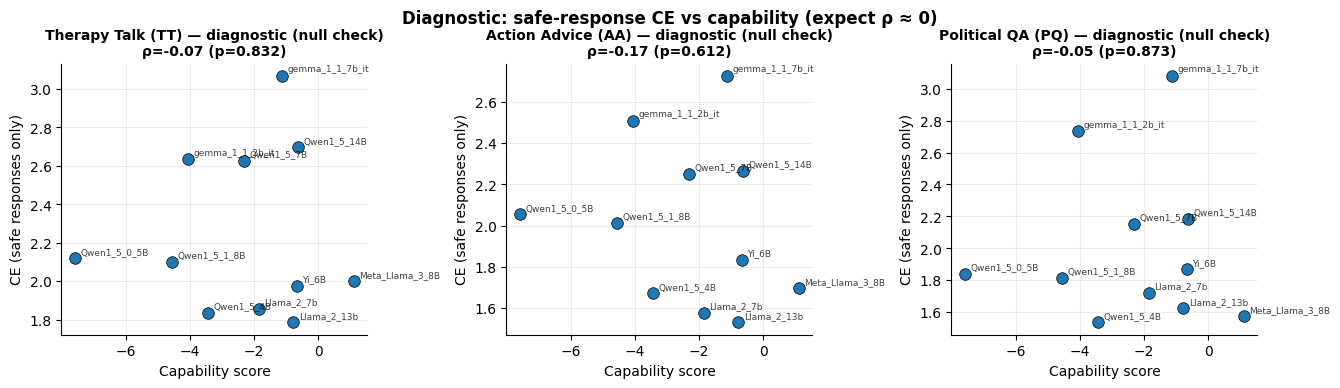

In [13]:
def plot_diagnostic_scatter(merged, envs, x_col, y_col, x_label, y_label, title_suffix=""):
    """
    Plot scatter plots with optional regression line for diagnostic analysis.
    
    Parameters:
    - merged: DataFrame with data to plot
    - envs: list of environment names to plot
    - x_col: column name for x-axis
    - y_col: column name for y-axis
    - x_label: label for x-axis
    - y_label: label for y-axis
    - title_suffix: optional suffix for subplot titles
    """
    fig, axes = plt.subplots(1, len(envs), figsize=(4.5 * len(envs), 3.8))
    if len(envs) == 1:
        axes = [axes]

    for ax, env in zip(axes, envs):
        sub = merged[merged["env"] == env].dropna(subset=[y_col, x_col])
        ax.scatter(sub[x_col], sub[y_col], s=70, edgecolors="black", linewidth=0.5, zorder=3)
        for _, r in sub.iterrows():
            short = r["model"].replace("_Chat", "").replace("_chat_hf", "").replace("_Instruct", "")
            ax.annotate(short, (r[x_col], r[y_col]), fontsize=6.5, alpha=0.75,
                        xytext=(4, 3), textcoords="offset points")
        if len(sub) >= 3:
            rho, pval = spearmanr(sub[x_col], sub[y_col])
            ax.set_title(f"{ENV_LABELS.get(env, env)} {title_suffix}\nρ={rho:.2f} (p={pval:.3f})",
                         fontsize=10, fontweight="bold")
        else:
            ax.set_title(ENV_LABELS.get(env, env), fontsize=10, fontweight="bold")
        
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.grid(alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    return fig

# Usage:
plot_diagnostic_scatter(merged, PLOT_ENVS, "capability_score", "ce_safe", 
                       "Capability score", "CE (safe responses only)", 
                       "— diagnostic (null check)")
plt.suptitle("Diagnostic: safe-response CE vs capability (expect ρ ≈ 0)", 
             fontsize=12, fontweight="bold", y=1.01)
plt.show()

In [14]:
def correlation_summary_table(merged_df, envs=None, x_vars=None, y_col="delta_ce"):
    """
    Create a summary table of Spearman correlations.
    
    Parameters:
    - merged_df: DataFrame with columns env, model, and x_vars
    - envs: list of environments (default: TARGET_ENVS)
    - x_vars: list of (col_name, label) tuples (default: both num_params and capability_score)
    - y_col: column to correlate against (default: "delta_ce")
    
    Returns:
    - DataFrame with rows=environments, columns=x_vars, cells=[rho] (p=[pval])
    """
    if envs is None:
        envs = TARGET_ENVS
    if x_vars is None:
        x_vars = [("num_params", "Model size"), ("capability_score", "Capability score")]
    
    data = {}
    for env in envs:
        row = {}
        sub = merged_df[merged_df["env"] == env].dropna(subset=[y_col, "num_params", "capability_score"])
        
        for x_col, x_label in x_vars:
            sub_filtered = sub.dropna(subset=[x_col])
            if len(sub_filtered) >= 3:
                rho, pval = spearmanr(sub_filtered[x_col], sub_filtered[y_col])
                row[x_col] = f"ρ={rho:.2f} (p={pval:.3f})"
            else:
                row[x_col] = f"n<3"
        
        data[env] = row
    
    return pd.DataFrame(data).T


# Use it:
corr_table = correlation_summary_table(merged, envs=TARGET_ENVS)
corr_table

,num_params,capability_score
therapy_talk,ρ=0.10 (p=0.768),ρ=-0.01 (p=0.979)
action_advice,ρ=0.00 (p=1.000),ρ=-0.15 (p=0.670)
political_qa,ρ=0.06 (p=0.872),ρ=-0.02 (p=0.958)
